# Project Machine Learning: Prediksi Harga Kendaraan Bekas (Regresi)
**Tujuan:** Membangun model *Machine Learning* untuk memprediksi `price` (harga mobil) menggunakan beberapa algoritma, *hyperparameter tuning*, dan membandingkan performanya pada berbagai variasi *data splitting*.

In [2]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## 1. Data Understanding
- **Sumber Dataset:** Data diambil dari sekumpulan *file* CSV kendaraan bekas (Audi, BMW, Toyota, VW, Skoda, Vauxhall).
- **Fitur/Variabel:**
  - `model`: Model mobil (Kategorikal)
  - `year`: Tahun pembuatan (Numerik)
  - `transmission`: Jenis transmisi (Kategorikal)
  - `mileage`: Jarak tempuh mobil (Numerik)
  - `fuelType`: Jenis bahan bakar (Kategorikal)
  - `tax`: Pajak jalan (Numerik)
  - `mpg`: Konsumsi bahan bakar miles per gallon (Numerik)
  - `engineSize`: Kapasitas mesin (Numerik)
  - `price`: Harga mobil dalam Poundsterling (Numerik - Target Variable)

In [3]:
# 1. Load dan Gabungkan Dataset
files = ['audi.csv', 'bmw.csv', 'toyota.csv', 'vw.csv', 'skoda.csv', 'vauxhall.csv']
dfs = []

# Membaca masing-masing file dan menambahkan kolom 'brand'
for f in files:
    df = pd.read_csv(f)
    df['brand'] = f.split('.')[0].capitalize()
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print("Informasi Dataset:")
print(data.info())
print("\nStatistik Deskriptif:")
display(data.describe())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63243 entries, 0 to 63242
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         63243 non-null  object 
 1   year          63243 non-null  int64  
 2   price         63243 non-null  int64  
 3   transmission  63243 non-null  object 
 4   mileage       63243 non-null  int64  
 5   fuelType      63243 non-null  object 
 6   tax           63243 non-null  int64  
 7   mpg           63243 non-null  float64
 8   engineSize    63243 non-null  float64
 9   brand         63243 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 4.8+ MB
None

Statistik Deskriptif:


,year,price,mileage,tax,mpg,engineSize
count,63243.000000,63243.00000,63243.000000,63243.000000,63243.000000,63243.000000
mean,2017.105751,16765.17028,23323.347027,120.206900,54.493623,1.683132
std,2.132516,9718.05564,21819.768251,63.144719,17.779741,0.536990
min,1970.000000,450.00000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.00000,6745.000000,125.000000,45.600000,1.400000
50%,2017.000000,14249.00000,17580.000000,145.000000,53.300000,1.600000
75%,2019.000000,20991.00000,33000.000000,145.000000,61.400000,2.000000
max,2020.000000,145000.00000,323000.000000,580.000000,470.800000,6.600000


## 2. Data Preprocessing
Tahap ini mencakup pembersihan data (menghapus *outlier* ekstrem seperti mobil tahun 1970 atau harga di atas £100,000 yang bisa merusak model), serta melakukan **One-Hot Encoding** untuk mengubah data teks (Kategorikal) menjadi angka agar bisa diproses algoritma.

In [4]:
# 2.1 Cek Missing Values
print("Jumlah Missing Values per kolom:\n", data.isnull().sum())

# 2.2 Menangani Outlier (Filter tahun yang masuk akal dan harga wajar)
data = data[(data['year'] >= 2005) & (data['year'] <= 2021)]
data = data[(data['price'] < 100000)]

# 2.3 Encoding Data Kategorikal (One-Hot Encoding)
# Drop_first=True digunakan untuk menghindari Dummy Variable Trap
data_encoded = pd.get_dummies(data, drop_first=True)

# 2.4 Memisahkan Fitur (X) dan Target (y)
X = data_encoded.drop('price', axis=1)
y = data_encoded['price']

print(f"\nDimensi data X setelah di-encode: {X.shape}")

Jumlah Missing Values per kolom:
 model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
brand           0
dtype: int64

Dimensi data X setelah di-encode: (63123, 143)


## 3. Exploratory Data Analysis (EDA)
Melihat distribusi harga (*target*) dan korelasi fitur-fitur numerik terhadap harga mobil.

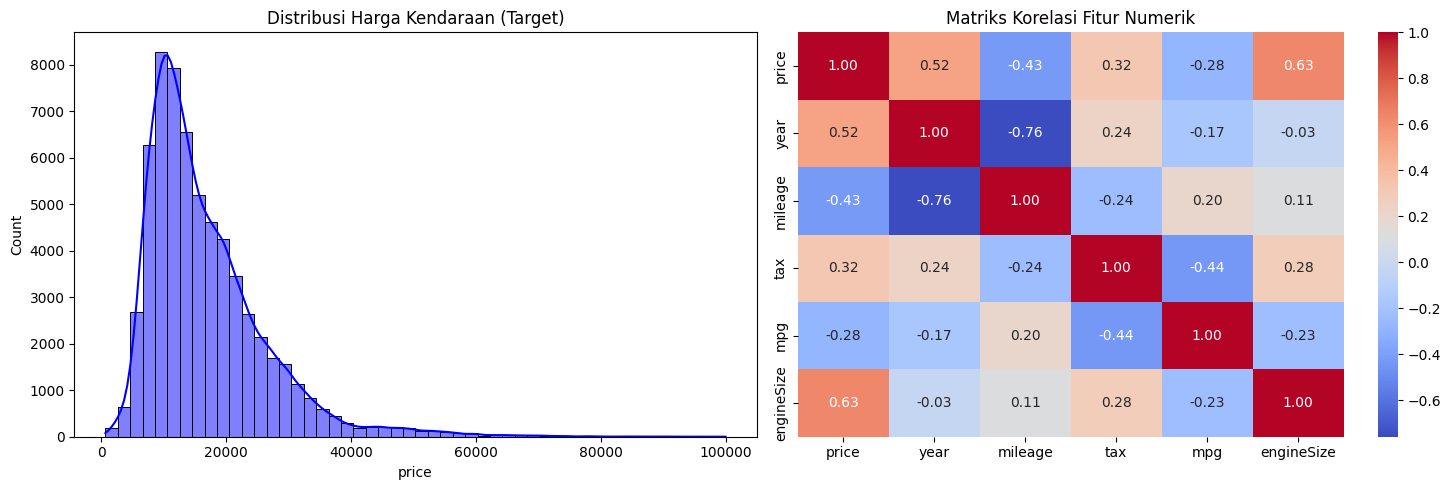

In [5]:
plt.figure(figsize=(15, 5))

# Plot Distribusi Harga
plt.subplot(1, 2, 1)
sns.histplot(data['price'], bins=50, kde=True, color='blue')
plt.title('Distribusi Harga Kendaraan (Target)')

# Plot Korelasi Fitur Numerik Utama (sebelum di-encode)
plt.subplot(1, 2, 2)
numeric_data = data[['price', 'year', 'mileage', 'tax', 'mpg', 'engineSize']]
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Fitur Numerik')

plt.tight_layout()
plt.show()

## 4, 5, 6, 7. Data Splitting, Model Building, Tuning & Evaluation
Pada tahap ini, kita akan melakukan eksekusi secara berulang (*loop*) untuk memenuhi syarat:
- 3 Variasi Split Data (70:30, 80:20, 90:10).
- 3 Algoritma (Decision Tree, Gradient Boosting, Random Forest).
- *Hyperparameter Tuning* menggunakan GridSearchCV dengan Cross-Validation (`cv=3`).
- Evaluasi Regresi (MAE, MSE, RMSE, R² Score).

In [6]:
# Definisi Proporsi Splitting
splits = {
    "70:30": 0.30,
    "80:20": 0.20,
    "90:10": 0.10
}

# Definisi Algoritma dan Parameter untuk di-Tuning
# Catatan: Grid disederhanakan agar proses running tidak berjam-jam
models = {
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {'max_depth': [10, 20]}
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {'n_estimators': [50, 100], 'learning_rate': [0.1]}
    },
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {'n_estimators': [50, 100], 'max_depth': [None, 20]}
    }
}

results_list = []

print("Mulai proses Training dan Tuning... (Tunggu beberapa menit)")

for split_name, test_size in splits.items():
    print(f"\n=== Proses Split Data {split_name} ===")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    for model_name, config in models.items():
        # Hyperparameter Tuning dengan Grid Search
        grid_search = GridSearchCV(config["model"], config["params"], cv=3, scoring='r2', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        
        # Prediksi menggunakan model terbaik
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test)
        
        # Perhitungan Metrik Evaluasi Regresi
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        # Simpan hasil
        results_list.append({
            "Split": split_name,
            "Model": model_name,
            "Best Params": str(grid_search.best_params_),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "R2 Score (%)": round(r2 * 100, 2)
        })
        print(f"[{model_name}] selesai ditraining. R2: {round(r2*100, 2)}%")

# Konversi hasil menjadi DataFrame
df_results = pd.DataFrame(results_list)

Mulai proses Training dan Tuning... (Tunggu beberapa menit)

=== Proses Split Data 70:30 ===
[Decision Tree] selesai ditraining. R2: 94.21%
[Gradient Boosting] selesai ditraining. R2: 91.62%
[Random Forest] selesai ditraining. R2: 96.29%

=== Proses Split Data 80:20 ===
[Decision Tree] selesai ditraining. R2: 93.77%
[Gradient Boosting] selesai ditraining. R2: 91.24%
[Random Forest] selesai ditraining. R2: 96.11%

=== Proses Split Data 90:10 ===
[Decision Tree] selesai ditraining. R2: 94.47%
[Gradient Boosting] selesai ditraining. R2: 91.29%
[Random Forest] selesai ditraining. R2: 96.46%


## 8. Model Comparison
Membandingkan performa dari keseluruhan eksperimen (Akurasi / $R^2$ Score dan Splitting).

TABEL PERBANDINGAN PERFORMA MODEL:



,Split,Model,Best Params,MAE,RMSE,R2 Score (%)
0,90:10,Random Forest,"{'max_depth': None, 'n_estimators': 50}",1148.78,1781.37,96.46
1,70:30,Random Forest,"{'max_depth': None, 'n_estimators': 100}",1153.24,1848.51,96.29
2,80:20,Random Forest,"{'max_depth': None, 'n_estimators': 100}",1147.84,1866.94,96.11
3,90:10,Decision Tree,{'max_depth': 20},1371.93,2225.30,94.47
4,70:30,Decision Tree,{'max_depth': 20},1390.04,2309.51,94.21
5,80:20,Decision Tree,{'max_depth': 20},1388.49,2362.77,93.77
6,70:30,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 100}",1942.67,2778.19,91.62
7,90:10,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 100}",1954.51,2792.93,91.29
8,80:20,Gradient Boosting,"{'learning_rate': 0.1, 'n_estimators': 100}",1960.27,2801.03,91.24


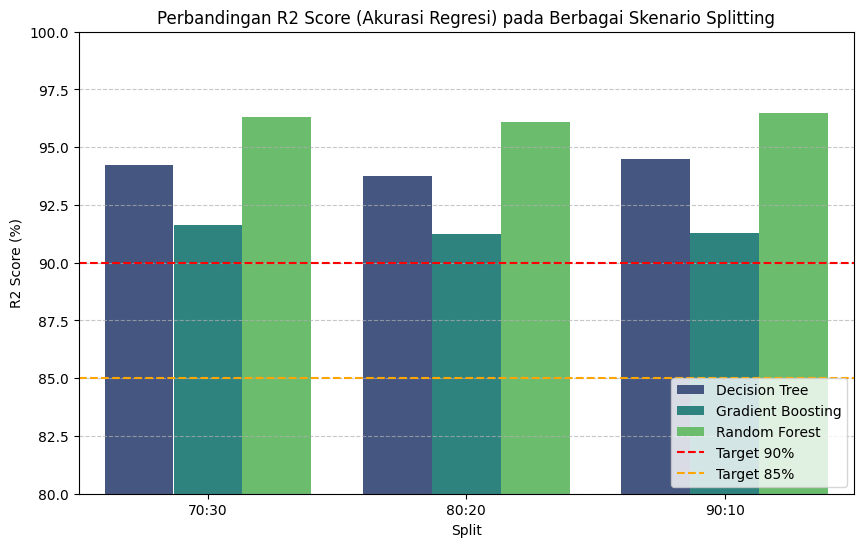

In [7]:
# Tampilkan Tabel Hasil Perbandingan Keseluruhan
print("TABEL PERBANDINGAN PERFORMA MODEL:\n")
display(df_results.sort_values(by="R2 Score (%)", ascending=False).reset_index(drop=True))

# Visualisasi Perbandingan Model
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Split', y='R2 Score (%)', hue='Model', palette='viridis')
plt.title('Perbandingan R2 Score (Akurasi Regresi) pada Berbagai Skenario Splitting')
plt.axhline(y=90, color='r', linestyle='--', label='Target 90%')
plt.axhline(y=85, color='orange', linestyle='--', label='Target 85%')
plt.ylim(80, 100) # Memfokuskan grafik pada rentang akurasi tinggi
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 9. Evaluasi Model (Diagnosa Overfitting & Underfitting)
Pada tahap ini, kita akan melatih ulang model menggunakan salah satu porsi data (misalnya 80:20) dan membandingkan performa model terhadap `Data Training` vs `Data Testing` untuk mendeteksi *overfitting* atau *underfitting*.

In [8]:
# Menggunakan proporsi 80:20 untuk evaluasi mendalam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Inisialisasi model dengan parameter yang umumnya optimal
eval_models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=15, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
}

diagnosa_results = []

print("Mengevaluasi Model pada Data Training vs Testing...\n")

for name, model in eval_models.items():
    model.fit(X_train, y_train)
    
    # 1. Prediksi & Evaluasi Data Training
    y_train_pred = model.predict(X_train)
    r2_train = r2_score(y_train, y_train_pred)
    
    # 2. Prediksi & Evaluasi Data Testing
    y_test_pred = model.predict(X_test)
    r2_test = r2_score(y_test, y_test_pred)
    
    # 3. Hitung Selisih
    selisih = r2_train - r2_test
    
    # 4. Logika Diagnosa
    status = "Good Fit (Optimal)"
    if r2_train < 0.75 and r2_test < 0.75:
        status = "Underfitting"
    elif selisih > 0.08: # Jika selisih R2 lebih dari 8%
        status = "Overfitting (Terlalu Menghafal Data)"
        
    diagnosa_results.append({
        "Model": name,
        "R2 Training (%)": round(r2_train * 100, 2),
        "R2 Testing (%)": round(r2_test * 100, 2),
        "Selisih (%)": round(selisih * 100, 2),
        "Diagnosa": status
    })

# Menampilkan Tabel Diagnosa
df_diagnosa = pd.DataFrame(diagnosa_results)
display(df_diagnosa)

Mengevaluasi Model pada Data Training vs Testing...



,Model,R2 Training (%),R2 Testing (%),Selisih (%),Diagnosa
0,Decision Tree,97.06,93.81,3.26,Good Fit (Optimal)
1,Gradient Boosting,91.33,91.24,0.09,Good Fit (Optimal)
2,Random Forest,98.73,96.07,2.66,Good Fit (Optimal)


## 10. Visualisasi Evaluasi: Prediksi vs Aktual
Grafik *scatter plot* ini digunakan untuk melihat seberapa akurat prediksi model Random Forest (model terbaik) dibandingkan dengan harga aslinya. Jika titik-titik mengikuti garis diagonal merah, berarti model memprediksi dengan sangat baik.

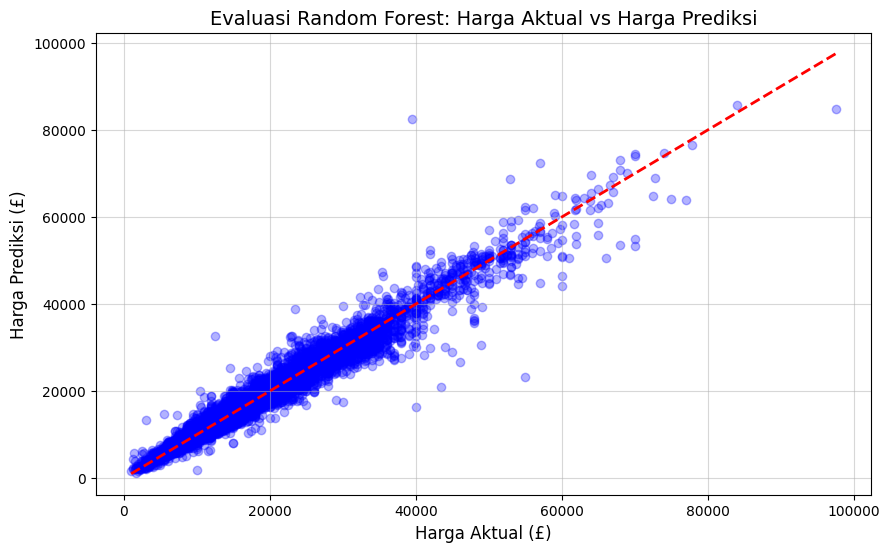

In [9]:
# Menggunakan Random Forest sebagai perwakilan visualisasi
rf_model = eval_models["Random Forest"]
y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')

# Membuat garis diagonal merah (Garis Sempurna)
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Evaluasi Random Forest: Harga Aktual vs Harga Prediksi', fontsize=14)
plt.xlabel('Harga Aktual (£)', fontsize=12)
plt.ylabel('Harga Prediksi (£)', fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

# 11. Evaluasi Model dalam Satuan IDR
Blok kode ini akan menghitung MAE (Mean Absolute Error) dan RMSE dalam Rupiah untuk menunjukkan rata-rata selisih harga prediksi model.

In [10]:
# Tentukan Kurs Konversi
KURS_IDR = 20000

# List untuk menyimpan hasil evaluasi IDR
eval_idr = []

print("EVALUASI MODEL (DALAM RUPIAH):")
for name, model in eval_models.items():
    y_pred = model.predict(X_test)
    
    # Hitung metrik dalam GBP
    mae_gbp = mean_absolute_error(y_test, y_pred)
    rmse_gbp = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Konversi ke IDR
    mae_idr = mae_gbp * KURS_IDR
    rmse_idr = rmse_gbp * KURS_IDR
    
    eval_idr.append({
        "Model": name,
        "R2 Score (%)": round(r2 * 100, 2),
        "Rata-rata Error (MAE IDR)": f"Rp {mae_idr:,.0f}",
        "Standar Error (RMSE IDR)": f"Rp {rmse_idr:,.0f}"
    })

df_eval_idr = pd.DataFrame(eval_idr)
display(df_eval_idr)

EVALUASI MODEL (DALAM RUPIAH):


,Model,R2 Score (%),Rata-rata Error (MAE IDR),Standar Error (RMSE IDR)
0,Decision Tree,93.81,"Rp 28,734,883","Rp 47,119,671"
1,Gradient Boosting,91.24,"Rp 39,205,418","Rp 56,020,585"
2,Random Forest,96.07,"Rp 23,056,915","Rp 37,520,612"


In [11]:
# Fungsi untuk Testing Model dengan Input Manual
def uji_prediksi_mobil(year, mileage, tax, mpg, engineSize, brand, model_name, transmission, fuelType):
    # Buat dictionary data baru (sesuaikan dengan kolom X yang sudah di-encode)
    # Kita mulai dengan data nol untuk semua kolom
    input_data = pd.DataFrame(0, index=[0], columns=X.columns)
    
    # Isi fitur numerik
    input_data['year'] = year
    input_data['mileage'] = mileage
    input_data['tax'] = tax
    input_data['mpg'] = mpg
    input_data['engineSize'] = engineSize
    
    # Isi fitur kategorikal (One-Hot Encoding manual)
    if f'brand_{brand.capitalize()}' in input_data.columns:
        input_data[f'brand_{brand.capitalize()}'] = 1
    if f'model_ {model_name}' in input_data.columns:
        input_data[f'model_ {model_name}'] = 1
    if f'transmission_{transmission}' in input_data.columns:
        input_data[f'transmission_{transmission}'] = 1
    if f'fuelType_{fuelType}' in input_data.columns:
        input_data[f'fuelType_{fuelType}'] = 1

    # Prediksi menggunakan Random Forest
    harga_gbp = rf_model.predict(input_data)[0]
    harga_idr = harga_gbp * KURS_IDR
    
    print(f"--- HASIL UJI COBA PREDIKSI ---")
    print(f"Mobil: {brand} {model_name} ({year})")
    print(f"Estimasi Harga: £{harga_gbp:,.2f}")
    print(f"Estimasi Harga (IDR): Rp {harga_idr:,.0f}")

# CONTOH UJI COBA:
# Coba ganti parameter di bawah ini untuk tes model
uji_prediksi_mobil(year=2019, mileage=15000, tax=145, mpg=50, engineSize=2.0, 
                   brand='Audi', model_name='A3', transmission='Manual', fuelType='Petrol')

--- HASIL UJI COBA PREDIKSI ---
Mobil: Audi A3 (2019)
Estimasi Harga: £17,024.44
Estimasi Harga (IDR): Rp 340,488,757


## 12. Perbandingan Harga Aktual vs Prediksi (Real Data)
Untuk melihat seberapa akurat model bekerja di dunia nyata, kita akan menyandingkan harga asli mobil dengan harga tebakan model (Random Forest), lalu menghitung selisih (error) dari tiap tebakan tersebut dalam Poundsterling dan Rupiah.

In [12]:
# 1. Mengambil prediksi dari model Random Forest (Model Terbaik)
rf_model = eval_models["Random Forest"]
y_pred_rf = rf_model.predict(X_test)

# 2. Membuat DataFrame perbandingan
df_compare = pd.DataFrame({
    'Harga Aktual (£)': y_test.values,
    'Harga Prediksi (£)': np.round(y_pred_rf, 2)
})

# 3. Menghitung Selisih / Error
df_compare['Selisih (£)'] = np.abs(df_compare['Harga Aktual (£)'] - df_compare['Harga Prediksi (£)'])

# 4. Mengonversi ke Rupiah (Asumsi 1 GBP = Rp 20.000)
KURS_IDR = 20000
df_compare['Harga Aktual (Rp)'] = df_compare['Harga Aktual (£)'] * KURS_IDR
df_compare['Harga Prediksi (Rp)'] = df_compare['Harga Prediksi (£)'] * KURS_IDR
df_compare['Selisih Error (Rp)'] = df_compare['Selisih (£)'] * KURS_IDR

# Format agar tampilan Rupiah lebih rapi (opsional)
pd.options.display.float_format = '{:,.0f}'.format

# 5. Menampilkan 15 sampel data acak dari Testing Set
print("SAMPEL PERBANDINGAN HARGA AKTUAL VS PREDIKSI:")
display(df_compare.sample(15, random_state=42).reset_index(drop=True))

SAMPEL PERBANDINGAN HARGA AKTUAL VS PREDIKSI:


,Harga Aktual (£),Harga Prediksi (£),Selisih (£),Harga Aktual (Rp),Harga Prediksi (Rp),Selisih Error (Rp)
0,10490,"10,048",442,209800000,"200,958,200","8,841,800"
1,13650,"14,087",437,273000000,"281,737,400","8,737,400"
2,39999,"43,114","3,115",799980000,"862,271,800","62,291,800"
3,7633,"8,573",940,152660000,"171,454,000","18,794,000"
4,30000,"30,050",50,600000000,"600,997,400","997,400"
5,8995,"9,472",477,179900000,"189,438,000","9,538,000"
6,6295,"5,989",306,125900000,"119,785,200","6,114,800"
7,26500,"27,176",676,530000000,"543,518,000","13,518,000"
8,22295,"21,365",930,445900000,"427,302,200","18,597,800"
9,16591,"16,134",457,331820000,"322,684,200","9,135,800"


### Visualisasi Sampel Aktual vs Prediksi
Tabel di atas menampilkan angka yang detail, namun grafik akan lebih mudah dipahami. Di bawah ini kita mengambil 50 sampel mobil pertama untuk memvisualisasikan seberapa dekat garis prediksi model mengikuti garis harga aslinya.

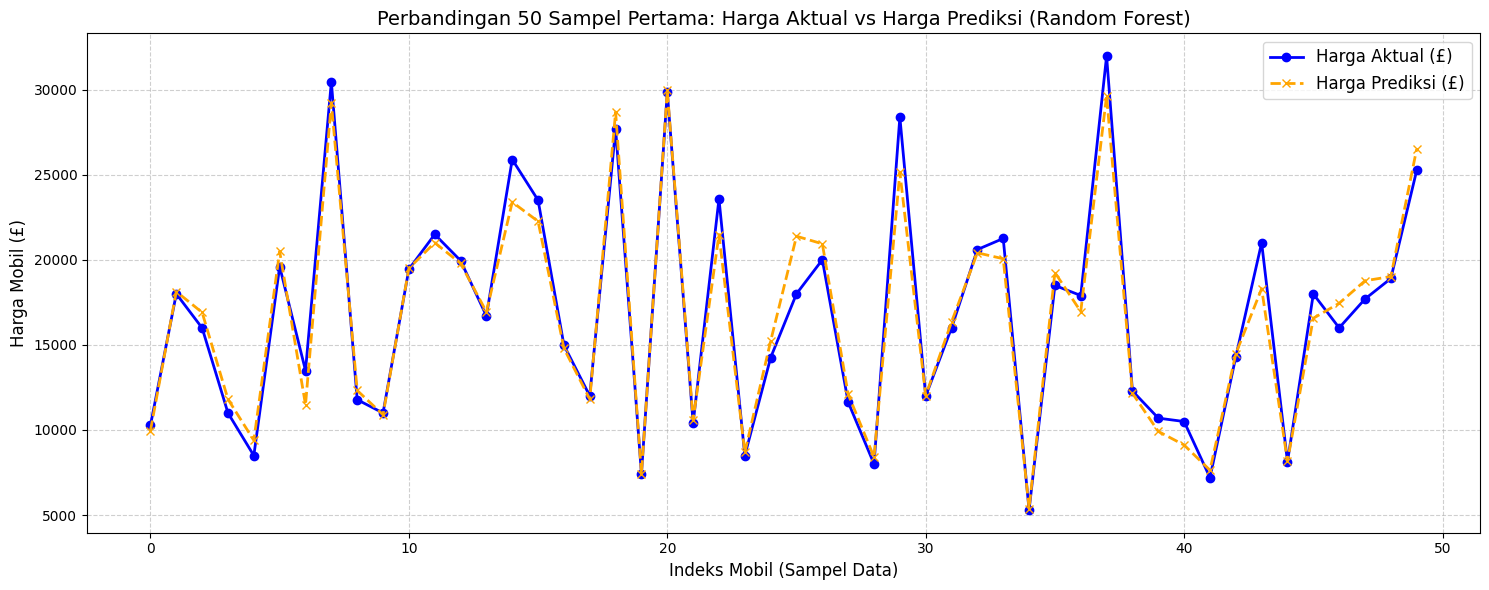

In [13]:
# Mengambil 50 data pertama agar grafik tidak terlalu padat
df_sample = df_compare.head(50)

plt.figure(figsize=(15, 6))

# Plot Harga Aktual (Garis Biru)
plt.plot(df_sample.index, df_sample['Harga Aktual (£)'], marker='o', color='blue', label='Harga Aktual (£)', linewidth=2)

# Plot Harga Prediksi (Garis Oranye)
plt.plot(df_sample.index, df_sample['Harga Prediksi (£)'], marker='x', color='orange', label='Harga Prediksi (£)', linestyle='dashed', linewidth=2)

# Desain Grafik
plt.title('Perbandingan 50 Sampel Pertama: Harga Aktual vs Harga Prediksi (Random Forest)', fontsize=14)
plt.xlabel('Indeks Mobil (Sampel Data)', fontsize=12)
plt.ylabel('Harga Mobil (£)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Kesimpulan dan Pemilihan Model Terbaik

Berdasarkan serangkaian eksperimen menggunakan tiga algoritma (Decision Tree, Gradient Boosting, dan Random Forest) dengan variasi rasio pembagian data (*data split*), kita dapat menarik kesimpulan sebagai berikut:

### 1. Perbandingan Performa Model (Skor $R^2$)
Model dievaluasi menggunakan metrik $R^2$ untuk mengukur seberapa baik model dapat menjelaskan variansi dari data target.
*  **Random Forest** secara konsisten mengungguli model lainnya pada semua skenario *split* data, dengan skor selalu berada di atas **96%** (Puncak tertinggi: 96.46%).
* **Decision Tree** menunjukkan performa kompetitif dan sangat baik di kisaran **93.7% - 94.4%**.
* **Gradient Boosting** berada di posisi ketiga, namun tetap memberikan hasil yang sangat layak di kisaran **91.2% - 91.6%**.

### 2. Evaluasi Rasio Pembagian Data (Data Split)
Variasi rasio *train-test split* (70:30, 80:20, 90:10) dilakukan untuk menguji stabilitas model:
* Performa model sangat stabil dan konsisten. Hal ini mengindikasikan bahwa model dapat menangkap pola data dengan baik tanpa indikasi *overfitting* yang berlebihan akibat perubahan jumlah data latih.
* Meskipun skor $R^2$ tertinggi untuk Random Forest dicapai pada rasio **90:10 (96.46%)**, penggunaan rasio **80:20 (96.11%)** atau **70:30 (96.29%)** jauh lebih disarankan untuk dipilih sebagai model final. Alasannya, rasio 70:30 atau 80:20 menyisakan data pengujian yang lebih banyak, sehingga validasi performa model pada data yang belum pernah dilihat (*unseen data*) menjadi lebih tepercaya.

### 3. Keputusan Final
Model **Random Forest** ditetapkan sebagai model final untuk diproduksi (*deployment*). Model ini terbukti paling tangguh (*robust*) dan memiliki tingkat akurasi prediksi regresi yang paling unggul dibandingkan algoritma lainnya.

---


## Contoh Implementasi

In [19]:
# 1. Membuat data spesifikasi mobil baru (Input Pengguna)
data_baru = {
    'brand': ['vw'],
    'model': ['Golf'],
    'year': [2018],
    'transmission': ['Manual'],
    'mileage': [30000],
    'fuelType': ['Petrol'],
    'tax': [145],
    'mpg': [55.4],
    'engineSize': [1.4]
}

df_baru = pd.DataFrame(data_baru)

# 2. Melakukan One-Hot Encoding pada data baru
df_baru_encoded = pd.get_dummies(df_baru)

# 3. Menyesuaikan kolom data baru dengan kolom saat Training (X_train)
# X_train_columns adalah daftar 143 kolom yang didapat dari tahap pelatihan
df_baru_encoded = df_baru_encoded.reindex(columns=X_train.columns, fill_value=0)

# 4. Melakukan Prediksi menggunakan model Random Forest terbaik
estimasi_harga_pound = rf_model.predict(df_baru_encoded)[0]

# 5. Konversi Matematika dari Poundsterling ke IDR (Rupiah)
kurs_pound_ke_rupiah = 20000  # Silakan ubah angka 20000 ini sesuai kurs asli saat ini
estimasi_harga_idr = estimasi_harga_pound * kurs_pound_ke_rupiah

# 6. Merapikan angkanya ke dalam teks format Rupiah
harga_idr_rapi = f"Rp {int(estimasi_harga_idr):,}".replace(',', '.')

# Menampilkan hasil
print(f"Spesifikasi Mobil: VW Golf (2018), Manual, 1.4L, 30.000 mil")
print(f"Estimasi Harga Jual (Poundsterling): £{estimasi_harga_pound:,.2f}")
print(f"Estimasi Harga Jual (Rupiah)     : {harga_idr_rapi}")


Spesifikasi Mobil: VW Golf (2018), Manual, 1.4L, 30.000 mil
Estimasi Harga Jual (Poundsterling): £9,791.09
Estimasi Harga Jual (Rupiah)     : Rp 195.821.833
